In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#EDA
df = pd.read_csv('personality_dataset.csv')

# Basic exploration
print(df.shape)
print(df.info())
print(df.describe())
print("\n\n\nMissing values:\n", df.isnull().sum())
print("Missing percentage:\n", (df.isnull().sum() / len(df)) * 100)
print(df['Personality'].value_counts())  # Check class balance

(2900, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   object 
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   object 
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB
None
       Time_spent_Alone  Social_event_attendance  Going_outside  \
count       2837.000000              2838.000000    2834.000000   
mean           4.505816                 3.963354       3.000000   
std            3.479192                 2.903827       2.247327 

### 1.Missing values to be filled
### 2.encoding has to be done 

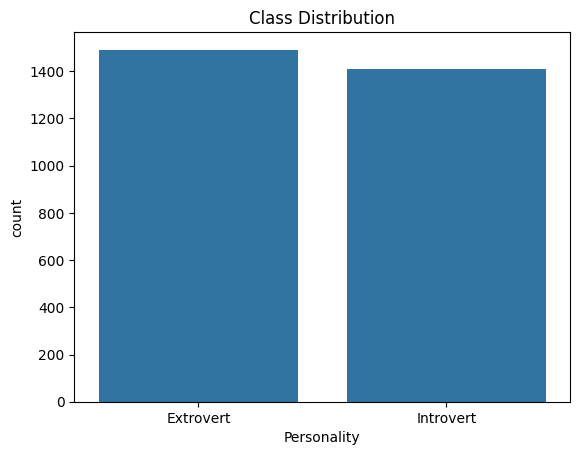

In [3]:
# class balance check
sns.countplot(x='Personality', data=df)
plt.title('Class Distribution')
plt.show()

# Class Imbalance details
#### *negligible amount of imbalance. 
### Counts:
### Extrovert   = 1491
### Introvert   = 1409

In [4]:
# 1. Check before 
print("Before:", df.isnull().sum().sum(), "missing values")

# Fill numerical columns with MEDIAN 
num_cols = ['Time_spent_Alone', 'Social_event_attendance',
            'Going_outside', 'Friends_circle_size', 'Post_frequency']

for col in num_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  {col:30s} filled with median = {median_val}")

# 3. Fill categorical columns with MODE
cat_cols = ['Stage_fear', 'Drained_after_socializing']

for col in cat_cols:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"  {col:30s} filled with mode  = '{mode_val}'")

# ── 4. Verify ─────────────────────────────────────────────────
print("\nAfter:", df.isnull().sum().sum(), "missing values")  # Should be 0
print(df.isnull().sum())

Before: 458 missing values
  Time_spent_Alone               filled with median = 4.0
  Social_event_attendance        filled with median = 3.0
  Going_outside                  filled with median = 3.0
  Friends_circle_size            filled with median = 5.0
  Post_frequency                 filled with median = 3.0
  Stage_fear                     filled with mode  = 'No'
  Drained_after_socializing      filled with mode  = 'No'

After: 0 missing values
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64


C:\Users\Harik\AppData\Local\Temp\ipykernel_30392\832763172.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
C:\Users\Harik\AppData\Local\Temp\ipykernel_30392\832763172.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [5]:
# Encode and map categorical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Yes/No → 1/0
df['Stage_fear']               = le.fit_transform(df['Stage_fear'])
df['Drained_after_socializing']= le.fit_transform(df['Drained_after_socializing'])

# Target: Extrovert=0, Introvert=1
df['Personality'] = le.fit_transform(df['Personality'])

# Confirm all numeric
print(df.dtypes)
print(df.head())

Time_spent_Alone             float64
Stage_fear                     int32
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing      int32
Friends_circle_size          float64
Post_frequency               float64
Personality                    int32
dtype: object
   Time_spent_Alone  Stage_fear  Social_event_attendance  Going_outside  \
0               4.0           0                      4.0            6.0   
1               9.0           1                      0.0            0.0   
2               9.0           1                      1.0            2.0   
3               0.0           0                      6.0            7.0   
4               3.0           0                      9.0            4.0   

   Drained_after_socializing  Friends_circle_size  Post_frequency  Personality  
0                          0                 13.0             5.0            0  
1                          1                  0.0             3.0            

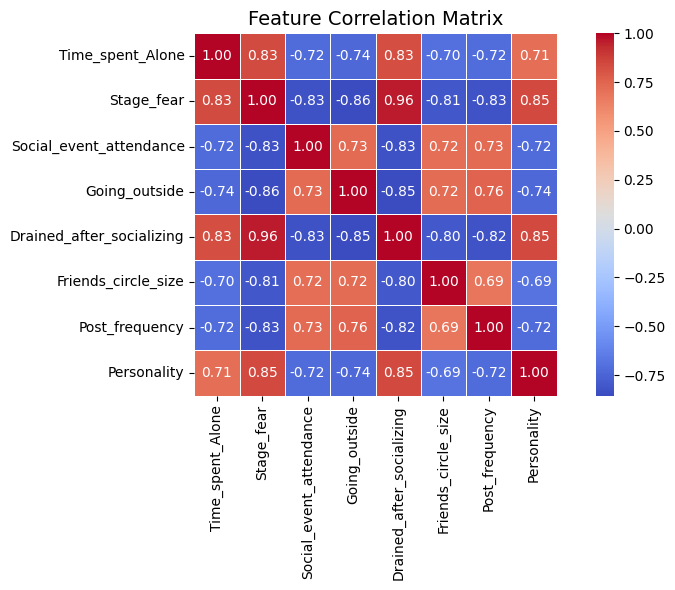

In [6]:
#Find correlation between features 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

## found critical correlations
#### Stage_fear  - Drained_after_socializing  =  +0.96  
#### Stage_fear  -  Time_spent_Alone           =  +0.83  
#### Stage_fear  -  Going_outside              =  -0.86  

## Issues
#### Multicollinearity risk: When predictors are highly correlated (like +0.96), they carry overlapping information. In regression or linear models, this can cause unstable coefficient estimates, inflated standard errors, and make it hard to interpret which variable is truly important.

#### Overfitting danger: Models may latch onto redundant signals, reducing generalization.

#### Interpretability issues: If you want to explain the effect of each variable, high correlations blur the distinction.

## Solution
### Tree based models such as Decision Tree , Random Forest , XGBoost

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split Features & Target 
X = df.drop('Personality', axis=1)
y = df['Personality']

#  Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% for testing
    random_state=42,     # reproducible results
    stratify=y           # keeps 51/49 ratio in both splits
)

print(f"X_train: {X_train.shape}") 
print(f"X_test:  {X_test.shape}")   
print(f"\nTrain class split:\n{y_train.value_counts()}")
print(f"\nTest class split:\n{y_test.value_counts()}")

# Scale Features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # transform test

# ! Note: the input to models should be scaled before predicting. [Excluded for tree based models]
# save scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as scaler.pkl")

X_train: (2320, 7)
X_test:  (580, 7)

Train class split:
Personality
0    1193
1    1127
Name: count, dtype: int64

Test class split:
Personality
0    298
1    282
Name: count, dtype: int64
Scaler saved as scaler.pkl


            Model  Train Acc  Test Acc  Overfit Gap  F1 Score  AUC-ROC
Gradient Boosting     0.9392    0.9172       0.0220    0.9170   0.9598
              SVM     0.9388    0.9172       0.0216    0.9170   0.9473
          XGBoost     0.9681    0.9052       0.0629    0.9043   0.9486
    Random Forest     0.9841    0.9017       0.0823    0.8995   0.9452


C:\Users\Harik\AppData\Local\Temp\ipykernel_30392\1396146490.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)


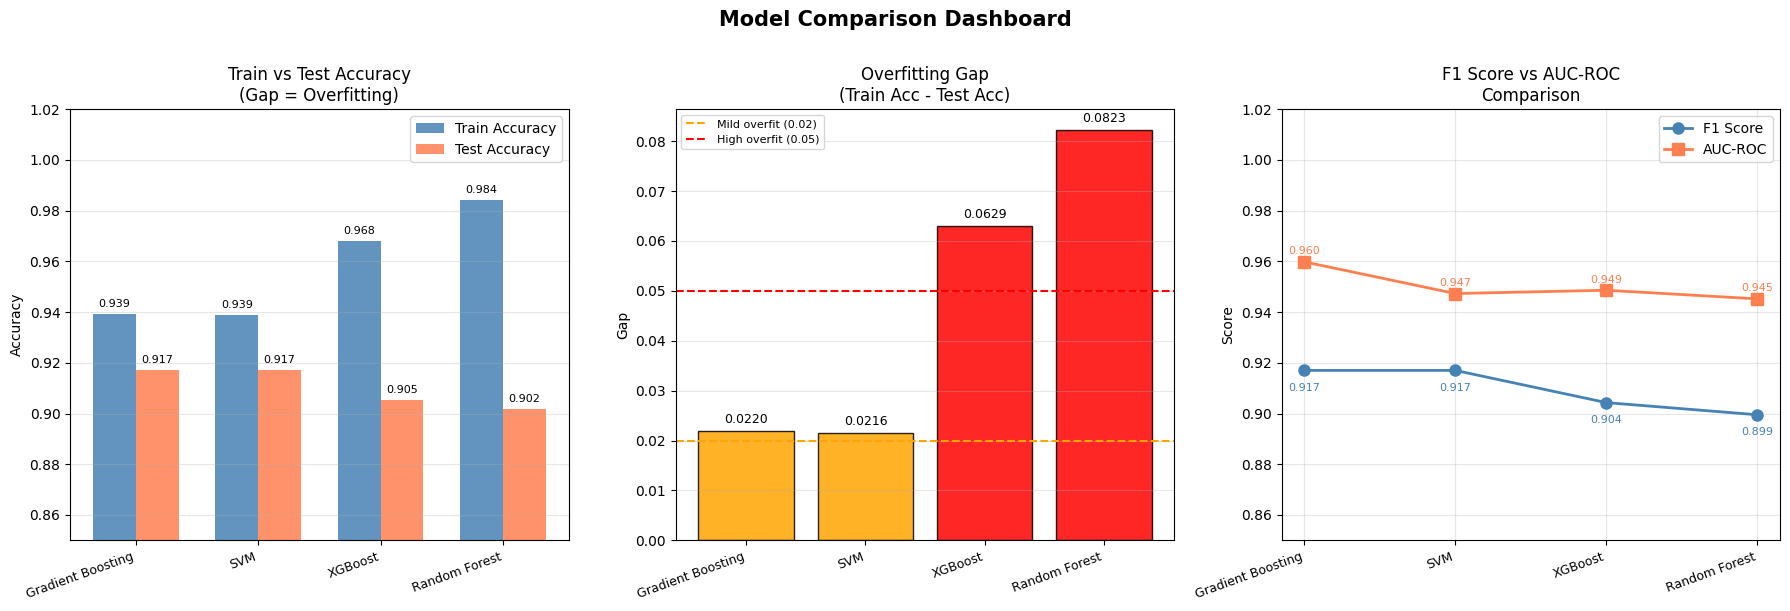

✅ Plot saved as model_comparison.png


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

models = {
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=42),
    "XGBoost"             : XGBClassifier(eval_metric='logloss', random_state=42),
    "SVM"                 : SVC(kernel='rbf', probability=True)
}

results = []

for name, model in models.items():
    X_tr = X_train_scaled if name in ["Logistic Regression", "SVM"] else X_train
    X_te = X_test_scaled  if name in ["Logistic Regression", "SVM"] else X_test

    model.fit(X_tr, y_train)

    # ── Train & Test Predictions ───────────────────────────────
    train_preds = model.predict(X_tr)
    test_preds  = model.predict(X_te)
    test_proba  = model.predict_proba(X_te)[:, 1]

    train_acc = accuracy_score(y_train, train_preds)
    test_acc  = accuracy_score(y_test,  test_preds)
    overfit   = round(train_acc - test_acc, 4)   # gap = overfitting indicator

    results.append({
        "Model"      : name,
        "Train Acc"  : round(train_acc, 4),
        "Test Acc"   : round(test_acc,  4),
        "Overfit Gap": overfit,
        "F1 Score"   : round(f1_score(y_test, test_preds), 4),
        "AUC-ROC"    : round(roc_auc_score(y_test, test_proba), 4)
    })

results_df = pd.DataFrame(results).sort_values("Test Acc", ascending=False)
print(results_df.to_string(index=False))

# ════════════════════════════════════════════════════════════════
# PLOT 1: Train vs Test Accuracy (Overfitting Check)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

model_names  = results_df["Model"].tolist()
train_accs   = results_df["Train Acc"].tolist()
test_accs    = results_df["Test Acc"].tolist()
x            = np.arange(len(model_names))
width        = 0.35

bars1 = axes[0].bar(x - width/2, train_accs, width, label='Train Accuracy',
                     color='steelblue', alpha=0.85)
bars2 = axes[0].bar(x + width/2, test_accs,  width, label='Test Accuracy',
                     color='coral',     alpha=0.85)

# Add value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0.85, 1.02)
axes[0].set_title('Train vs Test Accuracy\n(Gap = Overfitting)', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ════════════════════════════════════════════════════════════════
# PLOT 2: Overfitting Gap
# ════════════════════════════════════════════════════════════════
gaps   = results_df["Overfit Gap"].tolist()
colors = ['green' if g < 0.02 else 'orange' if g < 0.05 else 'red' for g in gaps]

bars = axes[1].bar(model_names, gaps, color=colors, alpha=0.85, edgecolor='black')

for bar, gap in zip(bars, gaps):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{gap:.4f}', ha='center', va='bottom', fontsize=9)

axes[1].axhline(y=0.02, color='orange', linestyle='--', label='Mild overfit (0.02)')
axes[1].axhline(y=0.05, color='red',    linestyle='--', label='High overfit (0.05)')
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Overfitting Gap\n(Train Acc - Test Acc)', fontsize=12)
axes[1].set_ylabel('Gap')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

# ════════════════════════════════════════════════════════════════
# PLOT 3: F1 Score + AUC-ROC Comparison
# ════════════════════════════════════════════════════════════════
f1_scores  = results_df["F1 Score"].tolist()
auc_scores = results_df["AUC-ROC"].tolist()

axes[2].plot(model_names, f1_scores,  marker='o', linewidth=2,
             color='steelblue', label='F1 Score',  markersize=8)
axes[2].plot(model_names, auc_scores, marker='s', linewidth=2,
             color='coral',     label='AUC-ROC',   markersize=8)

for i, (f1, auc) in enumerate(zip(f1_scores, auc_scores)):
    axes[2].text(i, f1  - 0.008, f'{f1:.3f}',  ha='center', fontsize=8, color='steelblue')
    axes[2].text(i, auc + 0.003, f'{auc:.3f}', ha='center', fontsize=8, color='coral')

axes[2].set_xticks(range(len(model_names)))
axes[2].set_xticklabels(model_names, rotation=20, ha='right', fontsize=9)
axes[2].set_ylim(0.85, 1.02)
axes[2].set_title('F1 Score vs AUC-ROC\nComparison', fontsize=12)
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Model Comparison Dashboard', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved as model_comparison.png")

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

# ════════════════════════════════════════════════════════════
# GRADIENT BOOSTING
# ════════════════════════════════════════════════════════════
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    {
        'n_estimators' : [100, 200, 300],
        'max_depth'    : [2, 3, 4],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample'    : [0.7, 0.8, 1.0]
    },
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
gb_grid.fit(X_train, y_train)
print(f"✅ GB    best params: {gb_grid.best_params_}")

# ════════════════════════════════════════════════════════════
# SVM
# ════════════════════════════════════════════════════════════
svm_grid = GridSearchCV(
    SVC(probability=True),
    {
        'C'      : [0.1, 1, 10, 100],   # regularization strength
        'kernel' : ['rbf', 'linear'],
        'gamma'  : ['scale', 'auto']    # influence of each sample
    },
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
svm_grid.fit(X_train_scaled, y_train)   # SVM needs scaled data
print(f"✅ SVM   best params: {svm_grid.best_params_}")

# ════════════════════════════════════════════════════════════
# XGBOOST
# ════════════════════════════════════════════════════════════
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [2, 3, 4],
        'learning_rate'   : [0.01, 0.05, 0.1],
        'subsample'       : [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    },
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)
print(f"✅ XGB   best params: {xgb_grid.best_params_}")

# ════════════════════════════════════════════════════════════
# RANDOM FOREST
# ════════════════════════════════════════════════════════════
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {
        'n_estimators': [100, 200, 300],
        'max_depth'   : [3, 5, 7, None],  # None = unlimited depth
        'min_samples_split': [2, 5, 10],  # min samples to split node
        'min_samples_leaf' : [1, 2, 4]    # min samples at leaf node
    },
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
print(f"✅ RF    best params: {rf_grid.best_params_}")

# ════════════════════════════════════════════════════════════
# COMPARE ALL TUNED MODELS
# ════════════════════════════════════════════════════════════
tuned_models = {
    "Gradient Boosting (Tuned)": (gb_grid.best_estimator_,  X_train,        X_test),
    "SVM (Tuned)"              : (svm_grid.best_estimator_, X_train_scaled, X_test_scaled),
    "XGBoost (Tuned)"          : (xgb_grid.best_estimator_, X_train,        X_test),
    "Random Forest (Tuned)"    : (rf_grid.best_estimator_,  X_train,        X_test),
}

tuned_results = []
for name, (model, X_tr, X_te) in tuned_models.items():
    train_preds = model.predict(X_tr)
    test_preds  = model.predict(X_te)
    test_proba  = model.predict_proba(X_te)[:, 1]

    train_acc = accuracy_score(y_train, train_preds)
    test_acc  = accuracy_score(y_test,  test_preds)

    tuned_results.append({
        "Model"      : name,
        "Train Acc"  : round(train_acc, 4),
        "Test Acc"   : round(test_acc,  4),
        "Overfit Gap": round(train_acc - test_acc, 4),
        "F1 Score"   : round(f1_score(y_test, test_preds), 4),
        "AUC-ROC"    : round(roc_auc_score(y_test, test_proba), 4)
    })

tuned_df = pd.DataFrame(tuned_results).sort_values("Test Acc", ascending=False)
print("\n")
print(tuned_df.to_string(index=False))

✅ GB    best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
✅ SVM   best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
✅ XGB   best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
✅ RF    best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


                    Model  Train Acc  Test Acc  Overfit Gap  F1 Score  AUC-ROC
Gradient Boosting (Tuned)     0.9388    0.9172       0.0216     0.917   0.9580
              SVM (Tuned)     0.9388    0.9172       0.0216     0.917   0.9169
          XGBoost (Tuned)     0.9388    0.9172       0.0216     0.917   0.9590
    Random Forest (Tuned)     0.9388    0.9172       0.0216     0.917   0.9623


🏆 Best Model: Random Forest (Tuned)
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



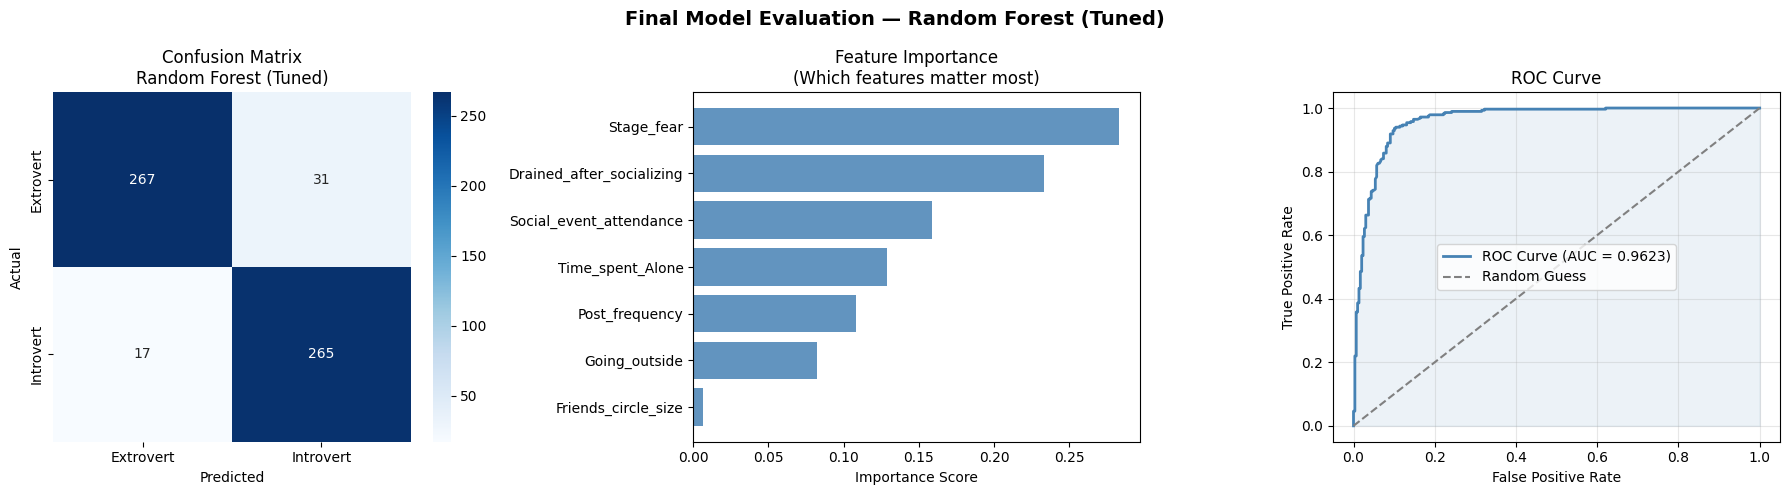

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc)
import pandas as pd

# ── Pick Best Model ───────────────────────────────────────────
best_model = rf_grid.best_estimator_
model_name = "Random Forest (Tuned)"

preds      = best_model.predict(X_test)
proba      = best_model.predict_proba(X_test)[:, 1]

# ── Classification Report ─────────────────────────────────────
print(f"🏆 Best Model: {model_name}")
print("="*50)
print(classification_report(y_test, preds,
      target_names=['Extrovert', 'Introvert']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Confusion Matrix ──────────────────────────────────
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Extrovert', 'Introvert'],
            yticklabels=['Extrovert', 'Introvert'])
axes[0].set_title(f'Confusion Matrix\n{model_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ── Plot 2: Feature Importance ────────────────────────────────
feat_df = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(feat_df['Feature'], feat_df['Importance'],
             color='steelblue', alpha=0.85)
axes[1].set_title('Feature Importance\n(Which features matter most)')
axes[1].set_xlabel('Importance Score')

# ── Plot 3: ROC Curve ─────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, proba)
roc_auc     = auc(fpr, tpr)

axes[2].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[2].plot([0,1], [0,1], color='gray', linestyle='--', label='Random Guess')
axes[2].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(f'Final Model Evaluation — {model_name}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
# save model
joblib.dump(best_model, 'best_model.pkl')
print("Best model saved as best_model.pkl") #random forest (tuned) performed best, so we save it for future use

NameError: name 'joblib' is not defined

## ! Since the best model so far is Random forest we dont have to use the scaler in the inputs for predictions